In [1]:
#데이터 폴더와 종류 입력
folder = './minet'
target_label = ['biotite', 'bornite', 'chrysocolla', 'malachite', 
                'muscovite', 'pyrite', 'quartz']

In [2]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

#데이터세트 지정과 사이즈, 종류 확인
dataset = ImageFolder(folder, transform=transforms.ToTensor())
print('Data size: ',len(dataset))
dataset.classes

Data size:  957


['biotite',
 'bornite',
 'chrysocolla',
 'malachite',
 'muscovite',
 'pyrite',
 'quartz']

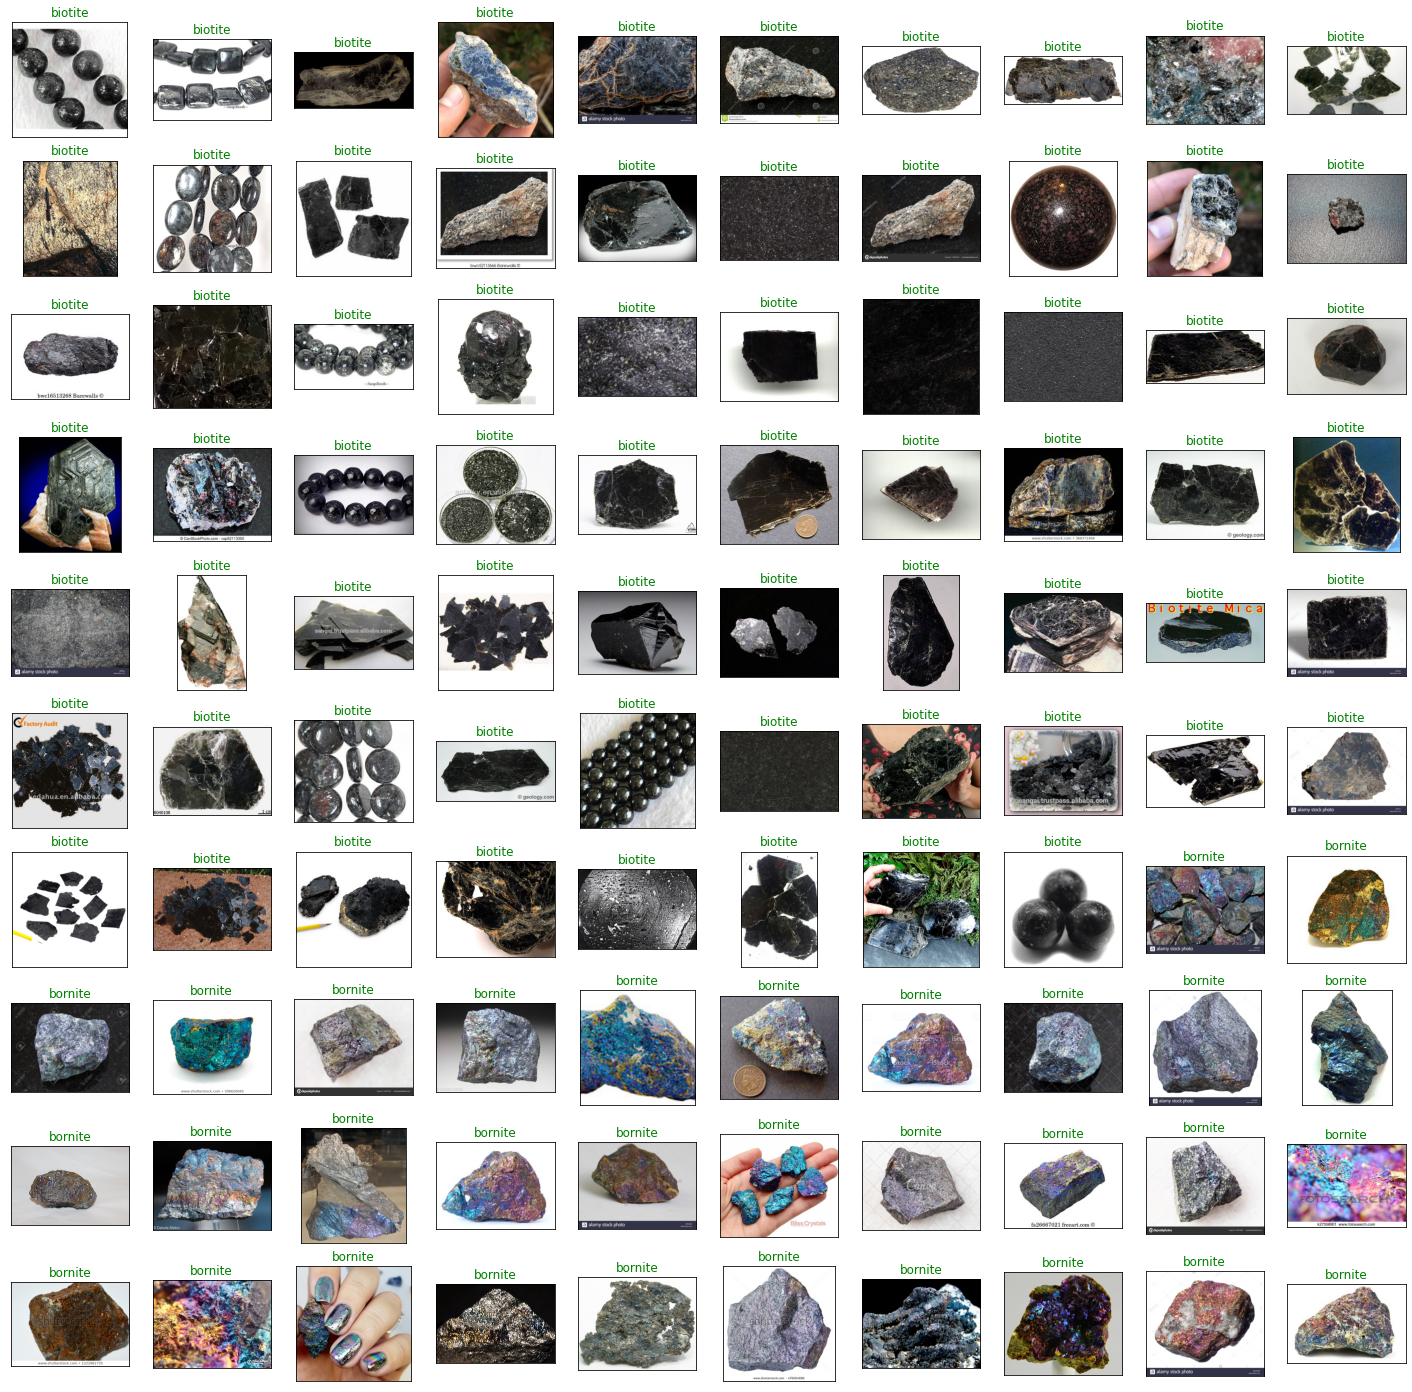

In [3]:
#사진 데이터 확인

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(25, 25))

for i in range(100):
    image, label = dataset[i]
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks = [])
    ax.imshow(image.permute(1,2,0))
    ax.set_title(target_label[label], color='green')

In [4]:
#광물 종류와 개수 확인
import pandas as pd
import numpy as np

count = {}

for i in range(len(dataset)):
    _, labels = dataset[i]
    label = target_label[labels]
    if label not in count:
        count[label] = 1
    elif label in count:
        count[label] += 1

df = pd.DataFrame(count, index=np.arange(1))
df = df.transpose().reset_index()
df.columns = ['Mineral', 'count']
df

,Mineral,count
0,biotite,68
1,bornite,170
2,chrysocolla,164
3,malachite,235
4,muscovite,77
5,pyrite,98
6,quartz,145


In [5]:
#최소,최대 길이와 높이 확인

height = []
weight = []

for i in range(len(dataset)):
    image, label = dataset[i]
    height.append(image.size(1))
    weight.append(image.size(2))
    
print(f"maximum_height:{np.max(height)} \tminimum_height:{np.min(height)} \tmean_height:{np.mean(height)}")
print(f"maximum_weight:{np.max(weight)} \tminimum_weight:{np.min(weight)} \tmean_weight:{np.mean(weight)}")

maximum_height:6016 	minimum_height:129 	mean_height:696.6415882967607
maximum_weight:6016 	minimum_weight:144 	mean_weight:806.183908045977


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

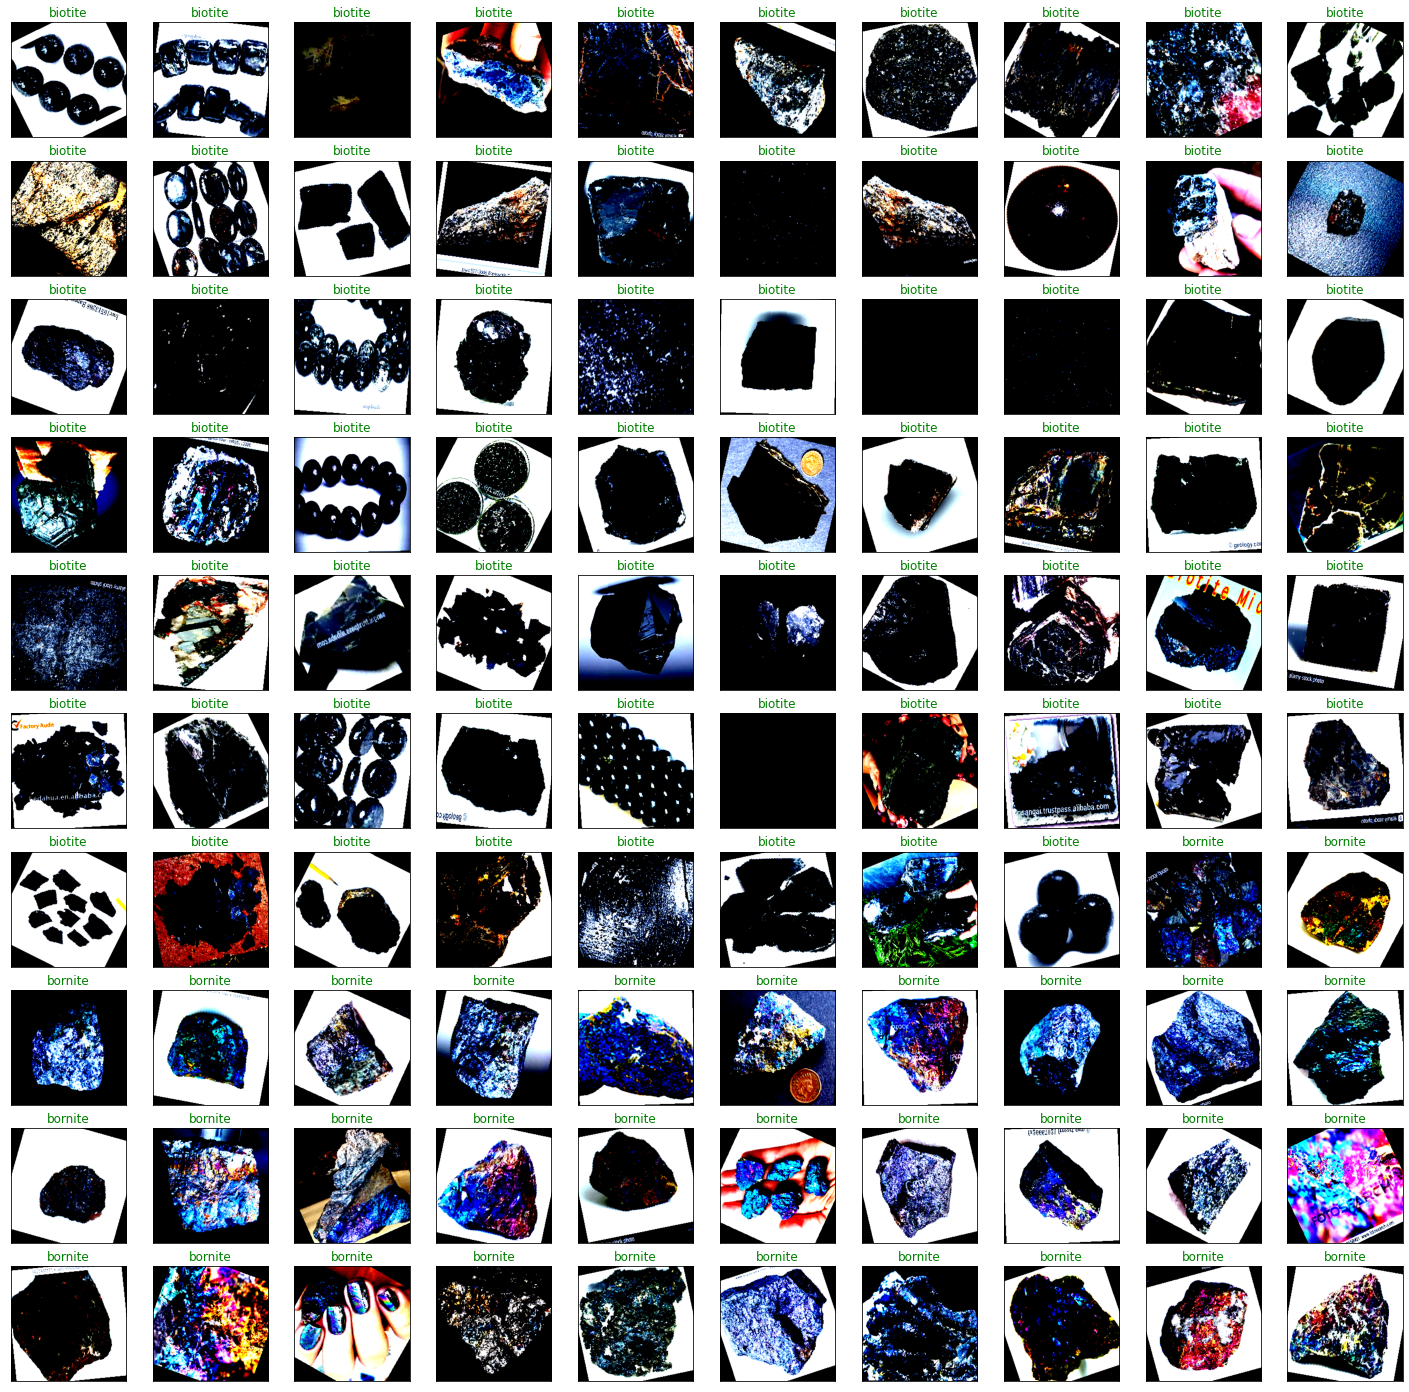

In [6]:
#이미지 정규화 후 데이터 사진확인

data_transform = transforms.Compose([transforms.Resize((224, 224)), 
                                     transforms.RandomRotation(30), 
                                     transforms.RandomVerticalFlip(p=0.5),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])])
load_data = ImageFolder(folder, transform=data_transform)

fig = plt.figure(figsize=(25, 25))
for i in range(100):
    image, label = load_data[i]
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks = [])
    ax.imshow(image.permute(1,2,0))
    ax.set_title(target_label[label], color='green')

In [7]:
#plot_dist 함수지정(데이터 분포 보는 함수)
from collections import Counter

def plot_dist(indexes, dataset=dataset):
    #dist = {}
    count = Counter()
    for i in indexes:
        _, label = dataset[i]
        count[target_label[label]] += 1
        
    dist_2 = dict(sorted(count.items(), key=lambda kv: kv[1], reverse=True))
    plt.bar(dist_2.keys(), dist_2.values())
    plt.xticks(rotation=30)
    plt.title('Data distribution'); plt.ylabel('count')
    plt.show()

In [8]:
#랜덤으로 train, val값에 데이터를 나누어 넣음
from sklearn.model_selection import train_test_split

idx_label = {}

for i in range(len(dataset)):
    _, label = dataset[i]
    idx_label[i] = label
x_train, x_test, y_train, y_test = train_test_split(list(idx_label.keys()), list(idx_label.values()), 
                                                  stratify = list(idx_label.values()), test_size=0.05)

print(len(x_train))
print(len(x_test))

909
48


In [9]:
x_train

[678,
 189,
 395,
 699,
 725,
 320,
 826,
 696,
 104,
 144,
 902,
 364,
 93,
 54,
 750,
 257,
 664,
 29,
 690,
 756,
 388,
 476,
 881,
 779,
 207,
 842,
 101,
 338,
 927,
 898,
 653,
 460,
 772,
 201,
 494,
 219,
 651,
 76,
 757,
 244,
 161,
 771,
 206,
 344,
 365,
 317,
 389,
 818,
 397,
 127,
 797,
 96,
 65,
 302,
 330,
 361,
 69,
 386,
 255,
 53,
 706,
 51,
 809,
 883,
 349,
 652,
 777,
 512,
 366,
 394,
 612,
 864,
 673,
 143,
 659,
 1,
 80,
 496,
 401,
 768,
 174,
 193,
 253,
 900,
 45,
 119,
 776,
 74,
 737,
 296,
 901,
 762,
 710,
 327,
 850,
 469,
 649,
 954,
 340,
 21,
 42,
 682,
 846,
 79,
 916,
 622,
 254,
 945,
 251,
 162,
 466,
 527,
 573,
 542,
 928,
 329,
 447,
 956,
 482,
 267,
 875,
 99,
 354,
 746,
 309,
 477,
 486,
 9,
 885,
 400,
 277,
 176,
 714,
 838,
 870,
 646,
 198,
 921,
 665,
 165,
 516,
 468,
 576,
 713,
 829,
 554,
 275,
 191,
 689,
 555,
 493,
 754,
 10,
 7,
 153,
 72,
 492,
 243,
 227,
 938,
 807,
 563,
 500,
 609,
 261,
 585,
 241,
 70,
 88,
 738,
 318,


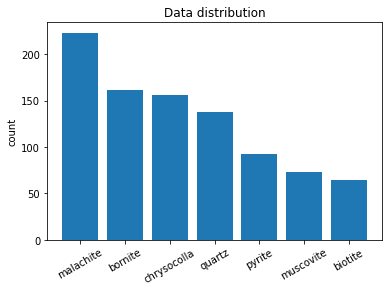

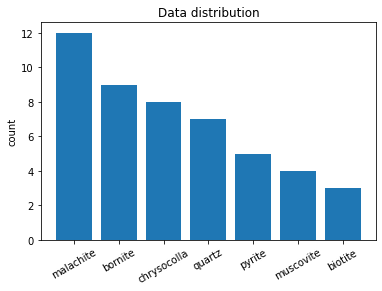

In [10]:
#앞서 만든 함수로 훈련데이터,테스트데이터 개수 시각화
plot_dist(x_train)
plot_dist(x_test)

In [11]:
#훈련세트, 테스트세트
from torch.utils.data import DataLoader, SubsetRandomSampler
    
batch_size = 32

train_set = SubsetRandomSampler(x_train)
test_set = SubsetRandomSampler(x_test)

train_loader = DataLoader(load_data, batch_size=batch_size, 
                          shuffle=False, num_workers=4, sampler= train_set)
test_loader = DataLoader(load_data, batch_size = 12,
                         shuffle=False, num_workers=4, sampler=test_set)

In [12]:
#토치비전 버전확인(0.10.0이며 다른버전은 지저분한 오류가뜸)
import torchvision

torchvision.__version__

'0.12.0'

In [13]:
for images, _ in train_loader:
    print('images.shape:', images.shape)
    print(images.size)

images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224c20>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224f90>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224b30>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224cc0>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224e50>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224360>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224ef0>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224bd0>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224db0>
images.shape: torch.Size([32, 3, 224, 224])
<built-in method size of Tensor object at 0x12f224b80>
images.sha

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


images.shape: tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.80

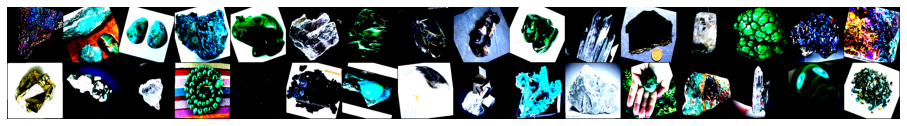

In [14]:
#하나의 배치에 대한 트레인로더 확인
from torchvision.utils import make_grid

for images, _ in train_loader:
    print('images.shape:', images)
    plt.figure(figsize=(16,16))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1, 2, 0)))
    break

In [138]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time

#device객체
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [139]:
#모델, 뉴런수 확인(전이학습)
model = models.resnet34(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [141]:
len(train_loader)

29

In [142]:
num_epochs = 50
model.train()
start_time = time.time()

# 전체 반복(epoch) 수 만큼 반복하며
for epoch in range(num_epochs):
    running_loss = 0.
    running_corrects = 0

    # 배치 단위로 학습 데이터 불러오기
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # 모델에 입력(forward)하고 결과 계산
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # 역전파를 통해 기울기(gradient) 계산 및 학습 진행
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_set)
    epoch_acc = running_corrects / len(train_set) * 100.
    
    torch.save(model, 'model_weights.pt')

    # 학습 과정 중에 결과 출력
    print('#{} Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch, epoch_loss, epoch_acc, time.time() - start_time))

#0 Loss: 1.6377 Acc: 41.8502% Time: 193.2027s
#1 Loss: 0.7549 Acc: 77.0925% Time: 398.9979s
#2 Loss: 0.4379 Acc: 87.3348% Time: 595.9400s
#3 Loss: 0.3129 Acc: 89.3172% Time: 791.0955s
#4 Loss: 0.2737 Acc: 91.6300% Time: 997.3476s
#5 Loss: 0.2350 Acc: 91.9604% Time: 1202.8781s
#6 Loss: 0.1854 Acc: 94.7137% Time: 1396.6850s
#7 Loss: 0.1225 Acc: 97.0264% Time: 1599.6076s
#8 Loss: 0.1389 Acc: 95.3745% Time: 1805.2996s
#9 Loss: 0.1081 Acc: 97.1366% Time: 1997.1282s
#10 Loss: 0.1044 Acc: 96.9163% Time: 2200.3041s
#11 Loss: 0.1305 Acc: 95.8150% Time: 2401.4401s
#12 Loss: 0.0988 Acc: 97.3568% Time: 2597.9269s
#13 Loss: 0.0736 Acc: 98.1278% Time: 2803.7856s
#14 Loss: 0.0678 Acc: 98.0176% Time: 2990.0646s
#15 Loss: 0.0634 Acc: 98.1278% Time: 3180.2749s
#16 Loss: 0.0667 Acc: 98.2379% Time: 3378.1651s
#17 Loss: 0.0726 Acc: 98.1278% Time: 3568.6344s
#18 Loss: 0.0447 Acc: 99.1189% Time: 3757.8169s
#19 Loss: 0.0482 Acc: 99.2291% Time: 3957.1732s
#20 Loss: 0.0447 Acc: 98.8987% Time: 4157.3449s
#21 Los

In [168]:
def showtime(input, title):
    # torch.Tensor를 numpy 객체로 변환
    input = input.numpy().transpose((1, 2, 0))
    # 이미지 정규화 해제하기
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input = std * input + mean
    input = np.clip(input, 0, 1)
    # 이미지 출력
    plt.imshow(input)
    plt.title(title)
    plt.show()

[예측 결과: muscovite] (실제 정답: muscovite)


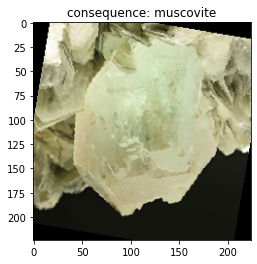

[예측 결과: malachite] (실제 정답: malachite)


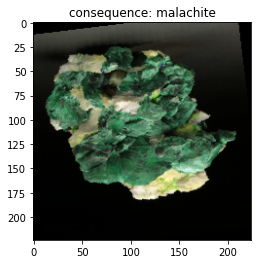

[예측 결과: bornite] (실제 정답: bornite)


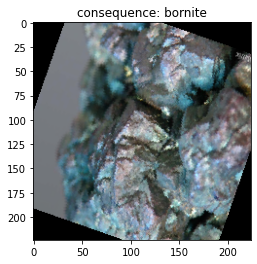

[예측 결과: quartz] (실제 정답: quartz)


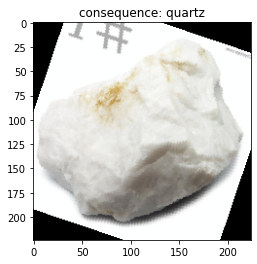

[Test Phase] Loss: 0.5004 Acc: 87.5000% Time: 22.9482s


In [184]:
from PIL import Image

model = torch.load('model_weights.pt')
model.eval()
start_time = time.time()

with torch.no_grad():
    running_loss = 0.
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        # 한 배치의 첫 번째 이미지에 대하여 결과 시각화
        print(f'[예측 결과: {target_label[preds[0]]}] (실제 정답: {target_label[labels.data[0]]})')
        showtime(inputs.cpu().data[0], title='consequence: ' + target_label[preds[0]])

    epoch_loss = running_loss / len(test_set)
    epoch_acc = running_corrects / len(test_set) * 100.
    print('[Test Phase] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch_loss, epoch_acc, time.time() - start_time))

In [ ]:
model = torch.load('model_weights.pt')
model.eval()
start_time = time.time()

with torch.no_grad():
    running_loss = 0.
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        # 한 배치의 첫 번째 이미지에 대하여 결과 시각화
        print(f'[예측 결과: {target_label[preds[0]]}] (실제 정답: {target_label[labels.data[0]]})')
        showtime(inputs.cpu().data[0], title='consequence: ' + target_label[preds[0]])

    epoch_loss = running_loss / len(test_set)
    epoch_acc = running_corrects / len(test_set) * 100.
    print('[Test Phase] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch_loss, epoch_acc, time.time() - start_time))